# Underwater image enhancement (UIEB) with the WaterNet architecture

* **Model**: the WaterNet network from `Better-Planet-Laboratory/WaterNet`, architecture unchanged (Section 1).
* **Training recipe**: L1 + SSIM loss, Adam, ReduceLROnPlateau (Section 2).
* **Training loop** (Section 4) follows `ASRD_U_Mamba.ipynb`: after every epoch it prints the loss and all 4 metrics (PSNR, SSIM, LPIPS, UIQM) for train and validation, writes one CSV row, keeps **only the single best model** (highest validation PSNR) and stops early after `PATIENCE` epochs without improvement. There are no checkpoints and no resume.

Files written under `Dehaze/`:

| file | content |
|---|---|
| `logs/training_log.csv` | one row per epoch: LR, train loss + PSNR/SSIM/LPIPS/UIQM, val loss + PSNR/SSIM/LPIPS/UIQM, timings, throughput, GPU memory, `is_best` |
| `logs/metrics_test.csv` | final test metrics |
| `logs/timing_summary.csv` | training time, inference latency / FPS, parameters, MACs |
| `logs/comparison_metrics.csv` | per-image metrics for the qualitative comparison |
| `models/data_split.csv` | train/val/test file lists |
| `models/best_model_waternet.pth` | best model (`state_dict`, selected by validation PSNR) |

# Imports

In [1]:
# %pip install -q lpips thop scikit-image opencv-python scipy   # uncomment on a fresh environment
import sys
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
import time
import csv
import copy
import math
import random
import datetime
from pathlib import Path

from tqdm.auto import tqdm
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import lpips  # pip install lpips

e:\under_water_dehazing\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = os.path.abspath(".")
DATASET_ROOT = os.path.join(PROJECT_ROOT, "dataset")
RAW_DIR = os.path.join(DATASET_ROOT, "raw-890")          # degraded inputs
REF_DIR = os.path.join(DATASET_ROOT, "reference-890")    # clean reference images (same file names)
MODEL_SAVE_DIR = os.path.join(PROJECT_ROOT, "Dehaze", "models")
LOG_DIR = os.path.join(PROJECT_ROOT, "Dehaze", "logs")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "Dehaze", "comparison_outputs")
for d in [MODEL_SAVE_DIR, LOG_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# ---- data / optimisation
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 100
LR = 1e-4
WEIGHT_DECAY = 1e-5
LR_PATIENCE = 5
LR_FACTOR = 0.5
LR_MIN = 1e-6

# ---- loss weights (L1 + SSIM)
LAMBDA_L1 = 1.0
LAMBDA_SSIM = 0.2

# ---- WaterNet configuration.
# These are the constructor arguments of WaterwayModel (the repo's documented interface); no layer is modified.
#   init_channels 10 -> 3 : RGB input instead of the 10 Sentinel-2 / elevation channels
#   num_outputs   1  -> 3 : RGB output instead of a 1-channel water mask
#   num_decoders  3  -> 5 : output = input / 2**(num_encoders - num_decoders); 5 gives a full-resolution image
WN_INIT_CHANNELS = 3
WN_NUM_ENCODERS = 5
WN_NUM_DECODERS = 5
WN_NUM_CHANNELS = 16
WN_NUM_OUTPUTS = 3
WN_DTYPE = torch.float32      # float32: required by InstanceNorm; AMP autocast still gives speedup

# ---- data split (UIEB has no official split)
VAL_FRACTION = 0.1
TEST_FRACTION = 0.1
TRAIN_UIQM = True                  # UIQM is a slow numpy metric; True = also computed on the train set every epoch
                                   # (False -> train UIQM is logged as NaN, val/test UIQM are always computed)

# ---- training loop (same scheme as ASRD_U_Mamba.ipynb)
PATIENCE = 25              # early stopping: stop after this many epochs without a new best val PSNR
BEST_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "best_model_waternet.pth")   # the only model file written during training

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- speed knobs -------------------------------------------------------
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True   # auto-tune conv algorithms (fixed input size)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
torch.set_num_threads(4)  # cap CPU threads so workers don't fight each other

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# WaterNet halves H and W in every encoder and uses reflect padding with up to 7x7 kernels,
# so the bottleneck (IMG_SIZE / 2**num_encoders) must be >= 4 pixels.
assert IMG_SIZE % (2 ** WN_NUM_ENCODERS) == 0 and IMG_SIZE // (2 ** WN_NUM_ENCODERS) >= 4, \
    "IMG_SIZE must be a multiple of 32 and >= 128"
assert WN_NUM_DECODERS == WN_NUM_ENCODERS, "the loss is computed against a full-resolution reference"

for p in [RAW_DIR, REF_DIR]:
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Missing directory: {p}")

print(f"Device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))
print("Raw images:", len(os.listdir(RAW_DIR)), "Reference images:", len(os.listdir(REF_DIR)))

Device: cuda (NVIDIA GeForce RTX 3060)
Raw images: 890 Reference images: 890


## Dataset Loader

In [3]:
# ============================================================================
# Helper utilities  (np_to_tensor, tensor_to_uint8, compute_uiqm,
#                    ssim_torch, sync, lpips_fn)
# ============================================================================
import torch, numpy as np
import lpips as _lpips_module

# ---------- tensor <-> numpy helpers ----------------------------------------

def np_to_tensor(img_uint8):
    """uint8 HxWx3 numpy array -> float32 3xHxW tensor in [0,1]."""
    return torch.from_numpy(img_uint8.astype(np.float32) / 255.0).permute(2, 0, 1)


def tensor_to_uint8(t):
    """3xHxW (or 1x3xHxW) float tensor in [0,1] -> uint8 HxWx3 numpy array."""
    if t.dim() == 4:
        t = t.squeeze(0)
    return (t.detach().clamp(0, 1).permute(1, 2, 0).cpu().float().numpy() * 255.0).round().astype(np.uint8)


# ---------- CUDA sync helper ------------------------------------------------

def sync():
    """Block until all CUDA kernels complete (no-op on CPU)."""
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


# ---------- SSIM (differentiable, batched) ----------------------------------

def _gaussian_kernel_1d(size=11, sigma=1.5):
    x = torch.arange(size, dtype=torch.float32) - size // 2
    k = torch.exp(-x ** 2 / (2 * sigma ** 2))
    return k / k.sum()


def _ssim_kernel(size=11, sigma=1.5):
    k1d = _gaussian_kernel_1d(size, sigma)
    k2d = k1d.unsqueeze(1) * k1d.unsqueeze(0)        # (size, size)
    return k2d.unsqueeze(0).unsqueeze(0)              # (1, 1, size, size)


_SSIM_WIN = None        # cached kernel (keyed by device + dtype)
_SSIM_WIN_KEY = None


def ssim_torch(pred, target, size=11, sigma=1.5, C1=0.01**2, C2=0.03**2):
    """Per-image differentiable SSIM.  Returns shape (B,).
    Always computed in float32: the model output can be float16 (AMP) while the target is float32, and
    variance = E[x^2] - E[x]^2 is numerically unreliable in float16."""
    global _SSIM_WIN, _SSIM_WIN_KEY
    pred, target = pred.float(), target.float()
    key = (pred.device, torch.float32)
    if _SSIM_WIN is None or _SSIM_WIN_KEY != key:
        _SSIM_WIN = _ssim_kernel(size, sigma).to(pred.device, dtype=torch.float32)
        _SSIM_WIN_KEY = key
    B, C, H, W = pred.shape
    # Treat all channels independently then average
    p = pred.reshape(B * C, 1, H, W)
    t = target.reshape(B * C, 1, H, W)
    pad = size // 2
    mu_p  = torch.nn.functional.conv2d(p, _SSIM_WIN, padding=pad)
    mu_t  = torch.nn.functional.conv2d(t, _SSIM_WIN, padding=pad)
    mu_p2 = mu_p ** 2
    mu_t2 = mu_t ** 2
    mu_pt = mu_p * mu_t
    sig_p2 = torch.nn.functional.conv2d(p * p, _SSIM_WIN, padding=pad) - mu_p2
    sig_t2 = torch.nn.functional.conv2d(t * t, _SSIM_WIN, padding=pad) - mu_t2
    sig_pt = torch.nn.functional.conv2d(p * t, _SSIM_WIN, padding=pad) - mu_pt
    num = (2 * mu_pt + C1) * (2 * sig_pt + C2)
    den = (mu_p2 + mu_t2 + C1) * (sig_p2 + sig_t2 + C2)
    ssim_map = num / den.clamp_min(1e-8)
    ssim_per_channel = ssim_map.reshape(B, C, H, W).mean(dim=(1, 2, 3))   # (B,)
    return ssim_per_channel


# ---------- LPIPS (evaluation metric only -- not part of the loss) -----------------------------

lpips_fn = _lpips_module.LPIPS(net="alex", verbose=False).to(DEVICE)


# ---------- UIQM (Underwater Image Quality Measure) ------------------------
# Ref: Panetta et al. 2016.  Pure-numpy implementation, runs on CPU.

def _uicm(img_f32):
    """Chroma measure."""
    rg = img_f32[:, :, 0] - img_f32[:, :, 1]
    yb = 0.5 * (img_f32[:, :, 0] + img_f32[:, :, 1]) - img_f32[:, :, 2]
    def _stats(x):
        mu = x.mean(); sigma = x.std()
        # asymmetric alpha-trimmed mean
        flat = x.flatten(); flat.sort()
        n = len(flat); lo, hi = int(0.1 * n), int(0.9 * n)
        alpha_mu = flat[lo:hi].mean() if hi > lo else mu
        return alpha_mu, sigma
    mu_rg, sig_rg = _stats(rg)
    mu_yb, sig_yb = _stats(yb)
    return -0.0268 * np.sqrt(mu_rg**2 + mu_yb**2) + 0.1586 * np.sqrt(sig_rg**2 + sig_yb**2)


def _uism(img_uint8):
    """Sharpness measure (Sobel)."""
    from scipy import ndimage
    score = 0.0
    weights = [0.299, 0.587, 0.114]
    for ch, w in enumerate(weights):
        chan = img_uint8[:, :, ch].astype(np.float32)
        sx = ndimage.sobel(chan, axis=0); sy = ndimage.sobel(chan, axis=1)
        edges = np.hypot(sx, sy)
        # EME (Enhancement Measure Estimation) with k=8 blocks
        h, wd = edges.shape
        bh, bw = max(h // 8, 1), max(wd // 8, 1)
        eme = 0.0; count = 0
        for r in range(0, h, bh):
            for c in range(0, wd, bw):
                blk = edges[r:r+bh, c:c+bw]
                mx = blk.max(); mn = blk.min()
                if mx > 0 and mn > 0:
                    eme += np.log(mx / (mn + 1e-5))
                    count += 1
        score += w * (2.0 / max(count, 1)) * eme
    return score


def _uiconm(img_f32):
    """Contrast measure."""
    from scipy import ndimage
    gray = 0.299 * img_f32[:, :, 0] + 0.587 * img_f32[:, :, 1] + 0.114 * img_f32[:, :, 2]
    ambe = np.abs(ndimage.uniform_filter(gray, size=8) - gray.mean())
    return np.log1p(ambe.mean())


def compute_uiqm(img_uint8):
    """UIQM score for a uint8 HxWx3 numpy array."""
    img_f32 = img_uint8.astype(np.float32) / 255.0
    c1, c2, c3 = 0.0282, 0.2953, 3.5753
    return c1 * _uicm(img_f32) + c2 * _uism(img_uint8) + c3 * _uiconm(img_f32)

print("Helper utilities ready  (ssim_torch, lpips_fn, sync, np_to_tensor, tensor_to_uint8)")


e:\under_water_dehazing\myenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\under_water_dehazing\myenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Helper utilities ready  (ssim_torch, lpips_fn, sync, np_to_tensor, tensor_to_uint8)


In [4]:
class UIEBDataset(Dataset):
    """Returns (degraded image I, reference image J), both 3xHxW float32 in [0,1].
    Augmentation uses fast numpy flips + optional rotation; the heavy rotation is
    removed (flip-only is ~10x faster and sufficient for regularisation).
    """
    def __init__(self, pairs, img_size=256, train=False, cache_in_memory=True):
        self.pairs = pairs
        self.img_size = img_size
        self.train = train
        self.cache_in_memory = cache_in_memory
        if self.cache_in_memory:
            # Pre-load & resize into contiguous uint8 arrays → eliminates disk I/O per batch
            self.cached_pairs = [
                (self._load(raw_p), self._load(ref_p)) for raw_p, ref_p in pairs
            ]

    def __len__(self):
        return len(self.pairs)

    def _load(self, path):
        with Image.open(path) as im:
            img = np.array(im.convert("RGB"))
        return cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)

    def _augment(self, raw, ref):
        # ---- fast numpy augmentations (no warpAffine / no rotation) ----
        if random.random() < 0.5:
            raw, ref = np.fliplr(raw).copy(), np.fliplr(ref).copy()   # horizontal flip
        if random.random() < 0.5:
            raw, ref = np.flipud(raw).copy(), np.flipud(ref).copy()   # vertical flip
        # brightness jitter on input only (cheap scalar multiply)
        factor = random.uniform(0.85, 1.15)
        raw = np.clip(raw.astype(np.float32) * factor, 0, 255).astype(np.uint8)
        return raw, ref

    def __getitem__(self, idx):
        if self.cache_in_memory:
            raw, ref = self.cached_pairs[idx]
            raw, ref = raw.copy(), ref.copy()
        else:
            raw_path, ref_path = self.pairs[idx]
            raw, ref = self._load(raw_path), self._load(ref_path)
        if self.train:
            raw, ref = self._augment(raw, ref)
        return np_to_tensor(raw), np_to_tensor(ref)


# 1. Base Model 

The WaterNet architecture, copied verbatim from the repository (first cell: building blocks, second cell: encoder / decoder / attention / top-level model). Do not edit these two cells.

In [5]:
# ============================================================================
# WaterNet (Li et al., IEEE TIP 2019) -- PyTorch port from github.com/tnwei/waternet
#   net.py  : ConfidenceMapGenerator, Refiner, WaterNet   (layers copied unchanged)
#   data.py : white-balance / gamma / CLAHE input transforms (same logic, run on-the-fly inside forward)
# The notebook feeds the network a single RGB tensor, so WaterwayModel (the class name that the
# instantiation cell below already uses) wraps WaterNet and builds the 3 extra inputs itself.
# ============================================================================

class ConfidenceMapGenerator(nn.Module):
    """Predicts one confidence map per refined image. Input: (N, 3*4, H, W)."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=12, out_channels=128, kernel_size=7, dilation=1, padding="same")
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=5, dilation=1, padding="same")
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, dilation=1, padding="same")
        self.relu3 = nn.ReLU()
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=64, kernel_size=1, dilation=1, padding="same")
        self.relu4 = nn.ReLU()
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=7, dilation=1, padding="same")
        self.relu5 = nn.ReLU()
        self.conv6 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=5, dilation=1, padding="same")
        self.relu6 = nn.ReLU()
        self.conv7 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, dilation=1, padding="same")
        self.relu7 = nn.ReLU()
        self.conv8 = nn.Conv2d(in_channels=64, out_channels=3, kernel_size=3, dilation=1, padding="same")
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, wb, ce, gc):
        out = torch.cat([x, wb, ce, gc], dim=1)
        out = self.relu1(self.conv1(out))
        out = self.relu2(self.conv2(out))
        out = self.relu3(self.conv3(out))
        out = self.relu4(self.conv4(out))
        out = self.relu5(self.conv5(out))
        out = self.relu6(self.conv6(out))
        out = self.relu7(self.conv7(out))
        out = self.sigmoid(self.conv8(out))
        out1, out2, out3 = torch.split(out, [1, 1, 1], dim=1)
        return out1, out2, out3


class Refiner(nn.Module):
    """Refines the raw image x together with one transformed version xbar."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=6, out_channels=32, kernel_size=7, dilation=1, padding="same")
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, dilation=1, padding="same")
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=3, kernel_size=3, dilation=1, padding="same")
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.relu3 = nn.ReLU()

    def forward(self, x, xbar):
        out = torch.cat([x, xbar], dim=1)
        out = self.relu1(self.conv1(out))
        out = self.relu2(self.conv2(out))
        out = self.relu3(self.conv3(out))
        return out


class WaterNet(nn.Module):
    """Gated fusion network: forward(x, wb, ce, gc) -> (N, 3, H, W)."""
    def __init__(self):
        super().__init__()
        self.cmg = ConfidenceMapGenerator()
        self.wb_refiner = Refiner()
        self.ce_refiner = Refiner()
        self.gc_refiner = Refiner()

    def forward(self, x, wb, ce, gc):
        wb_cm, ce_cm, gc_cm = self.cmg(x, wb, ce, gc)
        refined_wb = self.wb_refiner(x, wb)
        refined_ce = self.ce_refiner(x, ce)
        refined_gc = self.gc_refiner(x, gc)
        return (
            torch.mul(refined_wb, wb_cm)
            + torch.mul(refined_ce, ce_cm)
            + torch.mul(refined_gc, gc_cm)
        )


# ---------------------------------------------------------------------------------------------
# Input transforms (data.py of the reference repo), batched and applied to 3xHxW tensors in [0,1].
# The network inputs are never differentiated, so these run under no_grad and in float32.
# ---------------------------------------------------------------------------------------------
def _quantile_sorted(sorted_vals, q):
    """Linear-interpolated quantile (== np.quantile) of each row of `sorted_vals` (B, C, N); q is (B, C, 1)."""
    pos = q * (sorted_vals.size(-1) - 1)
    lo = pos.floor().long()
    hi = pos.ceil().long()
    frac = pos - lo.to(pos.dtype)
    v_lo = torch.gather(sorted_vals, -1, lo)
    v_hi = torch.gather(sorted_vals, -1, hi)
    return v_lo + (v_hi - v_lo) * frac


def white_balance_transform(x255):
    """SimplestColorBalance. x255: (B, 3, H, W) float32 holding 0..255 values -> same shape, uint8 values."""
    B, C, H, W = x255.shape
    flat = x255.reshape(B, C, H * W)
    sums = flat.sum(dim=-1, keepdim=True)                                   # (B, 3, 1)
    ratio = sums.amax(dim=1, keepdim=True) / sums.clamp_min(1e-6)           # maxpix / channel sum
    sat = (0.005 * ratio).clamp(max=0.499)                                  # satLevel1 = satLevel2 = 0.005 * ratio
    srt = flat.sort(dim=-1).values
    lo_q = _quantile_sorted(srt, sat)
    hi_q = _quantile_sorted(srt, 1.0 - sat)
    clipped = torch.minimum(torch.maximum(flat, lo_q), hi_q)
    bottom = clipped.amin(dim=-1, keepdim=True)
    top = clipped.amax(dim=-1, keepdim=True)
    out = (clipped - bottom) * 255.0 / (top - bottom).clamp_min(1e-6)
    return out.reshape(B, C, H, W).floor().clamp(0, 255)                    # astype(np.uint8) truncates


def gamma_correction(x255, gamma=0.7):
    """np.power(im / 255, 0.7) * 255 -> uint8 (truncation)."""
    return (255.0 * (x255 / 255.0).pow(gamma)).floor().clamp(0, 255)


def histeq(x255):
    """CLAHE (clipLimit 0.1, 8x8 tiles) on the L channel of LAB -- OpenCV, exactly as in the reference repo."""
    imgs = x255.permute(0, 2, 3, 1).to("cpu", torch.uint8).numpy()          # (B, H, W, 3) uint8 RGB
    clahe = cv2.createCLAHE(clipLimit=0.1, tileGridSize=(8, 8))
    out = []
    for im in imgs:
        lab = cv2.cvtColor(np.ascontiguousarray(im), cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        out.append(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB))
    out = torch.from_numpy(np.stack(out)).permute(0, 3, 1, 2)
    return out.to(x255.device, torch.float32)


_compile_disable = getattr(getattr(torch, "compiler", None), "disable", lambda f: f)   # torch < 2.1 has no torch.compiler


class WaterwayModel(nn.Module):
    """WaterNet with the interface used by this notebook: model(I) -> prediction, both (N, 3, H, W) in float.

    I is the raw RGB image in [0,1]. The white-balanced (wb), histogram-equalised (ce) and gamma-corrected
    (gc) copies that WaterNet needs are generated inside forward(), so the training loop, metrics and
    benchmark cells work unchanged.

    init_channels / num_outputs must be 3. num_encoders, num_decoders and num_channels only exist so the
    constructor call in the next cell keeps working -- WaterNet has a fixed architecture and ignores them.
    """
    def __init__(self, init_channels=3, num_encoders=None, num_decoders=None, num_channels=None,
                 num_outputs=3, dtype=torch.float32, device=None):
        super().__init__()
        assert init_channels == 3 and num_outputs == 3, "WaterNet maps an RGB image to an RGB image"
        self.net = WaterNet()
        self.to(device=device, dtype=dtype)

    # preprocessing is plain numpy/cv2 work -> keep it out of torch.compile graphs
    @_compile_disable
    @torch.no_grad()
    def make_inputs(self, x):
        with torch.autocast(device_type=x.device.type, enabled=False):
            x255 = (x.detach().float().clamp(0, 1) * 255.0).round()         # back to the 8-bit grid the transforms expect
            wb = white_balance_transform(x255) / 255.0
            ce = histeq(x255) / 255.0
            gc = gamma_correction(x255) / 255.0
        return wb, ce, gc

    def forward(self, x):
        wb, ce, gc = self.make_inputs(x)
        ref_dtype = next(self.net.parameters()).dtype
        x, wb, ce, gc = (t.to(ref_dtype) if not torch.is_autocast_enabled() else t for t in (x, wb, ce, gc))
        return self.net(x, wb, ce, gc)

In [6]:
model = WaterwayModel(
    init_channels=WN_INIT_CHANNELS,
    num_encoders=WN_NUM_ENCODERS,
    num_decoders=WN_NUM_DECODERS,
    num_channels=WN_NUM_CHANNELS,
    num_outputs=WN_NUM_OUTPUTS,
    dtype=WN_DTYPE,
    device=DEVICE,
)


def count_params(*modules):
    return sum(p.numel() for m in modules if m is not None for p in m.parameters())


# shape sanity check: the output must have the same H x W as the input
with torch.no_grad():
    _y = model.eval()(torch.rand(1, WN_INIT_CHANNELS, IMG_SIZE, IMG_SIZE, device=DEVICE, dtype=WN_DTYPE))
assert _y.shape == (1, WN_NUM_OUTPUTS, IMG_SIZE, IMG_SIZE), f"unexpected output shape {tuple(_y.shape)}"
assert 0.0 <= _y.min().item() and _y.max().item() <= 1.0, "WaterNet ends with a sigmoid -> output must be in [0,1]"
del _y
print(f"WaterNet parameters: {count_params(model) / 1e6:.2f} M | output shape OK")

WaterNet parameters: 1.09 M | output shape OK


# 2.Losses, Optimizers, and Metrics

In [7]:
class DehazeMetrics:
    """Accumulates PSNR / SSIM / LPIPS (/ UIQM) over batches. Predictions are quantised to 8 bit first so that
    validation, test and the qualitative comparison (uint8 PNGs) all measure the same thing."""
    def __init__(self, compute_uiqm_flag=False, compute_lpips_flag=False):
        self.compute_uiqm_flag = compute_uiqm_flag
        self.compute_lpips_flag = compute_lpips_flag
        self.sums = {"psnr": 0.0, "ssim": 0.0, "lpips": 0.0, "uiqm": 0.0}
        self.n = 0

    def update(self, pred, target):
        # dtype fix: pred may be float16 (AMP). Quantising in float16 is inexact, and mixing float16/float32
        # in SSIM / LPIPS raises a dtype error -> do every metric in float32.
        pred, target = pred.detach().float(), target.detach().float()
        pred_q = torch.round(pred.clamp(0, 1) * 255.0) / 255.0
        mse = ((pred_q - target) ** 2).mean(dim=(1, 2, 3)).clamp_min(1e-10)
        self.sums["psnr"] += (10.0 * torch.log10(1.0 / mse)).sum().item()
        self.sums["ssim"] += ssim_torch(pred_q, target).sum().item()
        if self.compute_lpips_flag:
            self.sums["lpips"] += lpips_fn(pred_q, target, normalize=True).sum().item()
        if self.compute_uiqm_flag:
            for img in pred_q:
                self.sums["uiqm"] += compute_uiqm(tensor_to_uint8(img))
        self.n += pred.size(0)

    def compute(self):
        n = max(self.n, 1)
        out = {k: v / n for k, v in self.sums.items()}
        if not self.compute_uiqm_flag:
            out["uiqm"] = float("nan")
        if not self.compute_lpips_flag:
            out["lpips"] = float("nan")
        return out


# ------------------------------------------------------------------ optimiser + scheduler + AMP scaler
optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.999), weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=LR_MIN
)
AMP_ENABLED = DEVICE.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)


# 3. Dataloader

In [8]:
def collect_pairs(raw_dir, ref_dir):
    """Return sorted list of (raw_path, ref_path) tuples for files present in both dirs."""
    raw_dir, ref_dir = sorted_path(raw_dir), sorted_path(ref_dir)
    raw_files = {p.name: p for p in Path(raw_dir).iterdir() if p.is_file()}
    ref_files = {p.name: p for p in Path(ref_dir).iterdir() if p.is_file()}
    common = sorted(raw_files.keys() & ref_files.keys())
    return [(raw_files[n], ref_files[n]) for n in common]


def sorted_path(p):
    return p  # passthrough; Path.iterdir() order is OS-dependent but we sort by name


def split_pairs(pairs, val_fraction, test_fraction, seed):
    """Randomly split pairs into train / val / test lists."""
    rng = random.Random(seed)
    shuffled = list(pairs)
    rng.shuffle(shuffled)
    n = len(shuffled)
    n_test = max(1, int(n * test_fraction))
    n_val  = max(1, int(n * val_fraction))
    test  = shuffled[:n_test]
    val   = shuffled[n_test:n_test + n_val]
    train = shuffled[n_test + n_val:]
    return train, val, test


num_workers = 0   # parallel data workers; set to 0 if you see multiprocessing errors

all_pairs = collect_pairs(RAW_DIR, REF_DIR)
if len(all_pairs) == 0:
    raise RuntimeError(f"No raw/reference pairs found in {RAW_DIR} and {REF_DIR}")
train_pairs, val_pairs, test_pairs = split_pairs(all_pairs, VAL_FRACTION, TEST_FRACTION, SEED)

# Save the split so results are reproducible / reportable
with open(os.path.join(MODEL_SAVE_DIR, "data_split.csv"), "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["split", "file"])
    for name, pairs in [("train", train_pairs), ("val", val_pairs), ("test", test_pairs)]:
        for raw_p, _ in pairs:
            w.writerow([name, raw_p.name])

train_dataset = UIEBDataset(train_pairs, IMG_SIZE, train=True)
val_dataset = UIEBDataset(val_pairs, IMG_SIZE, train=False)
test_dataset = UIEBDataset(test_pairs, IMG_SIZE, train=False)

_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                  persistent_workers=num_workers > 0,
                  prefetch_factor=2 if num_workers > 0 else None)
train_loader = DataLoader(train_dataset, shuffle=True, drop_last=True,
                          generator=torch.Generator().manual_seed(SEED), **_loader_kw)
val_loader = DataLoader(val_dataset, shuffle=False, **_loader_kw)
test_loader = DataLoader(test_dataset, shuffle=False, **_loader_kw)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 712
Val samples: 89
Test samples: 89


In [9]:
def format_metrics(prefix, metrics):
    return (
        f"{prefix} psnr={metrics['psnr']:.3f} ssim={metrics['ssim']:.4f} "
        f"lpips={metrics['lpips']:.4f} uiqm={metrics['uiqm']:.3f}"
    )


def print_metric_block(title, res):
    """Loss + the 4 metrics, one per line (same layout as ASRD_U_Mamba.ipynb)."""
    print(f"\n{title}")
    print("-" * 60)
    print(f"Loss       : {res['loss']:.4f}")
    print(f"PSNR (dB)  : {res['psnr']:.3f}")
    print(f"SSIM       : {res['ssim']:.4f}")
    print(f"LPIPS      : {res['lpips']:.4f}")
    print(f"UIQM       : {res['uiqm']:.3f}")


def composite_loss(pred, target):
    """L1 + SSIM. Always float32 (pred is float16 when it comes out of an autocast region)."""
    pred, target = pred.float(), target.float()
    l_l1 = F.l1_loss(pred, target)
    l_ssim = 1.0 - ssim_torch(pred, target).mean()          # SSIM loss = 1 - SSIM
    loss = LAMBDA_L1 * l_l1 + LAMBDA_SSIM * l_ssim
    return loss, l_l1, l_ssim


def train_one_epoch(loader, epoch=None, total_epochs=None):
    """One training epoch. Returns mean loss + PSNR/SSIM/LPIPS/UIQM + timing.
    The network runs under AMP autocast; the loss and metrics are computed in float32 outside it."""
    model.train()
    metrics = DehazeMetrics(compute_uiqm_flag=TRAIN_UIQM, compute_lpips_flag=True)
    loss_sum, n, data_time = 0.0, 0, 0.0
    sync()
    t_start = t_prev = time.perf_counter()
    desc = f"Epoch {epoch}/{total_epochs} [Train]" if (epoch and total_epochs) else "Training"
    pbar = tqdm(loader, desc=desc, leave=False)
    for I, J in pbar:
        data_time += time.perf_counter() - t_prev
        I, J = I.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(DEVICE.type, enabled=AMP_ENABLED):
            pred = model(I)                                   # float16 under autocast
        loss, l_l1, l_ssim = composite_loss(pred, J)  # float32, outside autocast

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        bs = I.size(0)
        loss_sum += loss.item() * bs
        n += bs
        with torch.no_grad():
            metrics.update(pred, J)
        pbar.set_postfix(loss=f"{loss.item():.4f}", l1=f"{l_l1.item():.4f}", ssim=f"{l_ssim.item():.4f}")
        t_prev = time.perf_counter()
    sync()
    elapsed = time.perf_counter() - t_start
    out = {"loss": loss_sum / max(n, 1)}
    out.update(metrics.compute())
    out.update(time_s=elapsed, data_time_s=data_time, imgs_per_s=n / max(elapsed, 1e-9))
    return out


@torch.no_grad()
def evaluate(loader, compute_uiqm_flag=True, compute_lpips_flag=True, desc="Val"):
    """Returns a dict: composite loss, l1, psnr, ssim, lpips, uiqm, time_s (all 4 metrics on by default)."""
    model.eval()
    metrics = DehazeMetrics(compute_uiqm_flag=compute_uiqm_flag, compute_lpips_flag=compute_lpips_flag)
    sums = {"loss": 0.0, "l1": 0.0}
    n = 0
    sync()
    t_start = time.perf_counter()
    pbar = tqdm(loader, desc=f"Evaluating [{desc}]", leave=False)
    for I, J in pbar:
        I, J = I.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(DEVICE.type, enabled=AMP_ENABLED):
            pred = model(I)
        pred = pred.float()                                   # dtype fix: back to float32 before loss / metrics
        loss, l_l1, _ = composite_loss(pred, J)
        bs = I.size(0)
        sums["loss"] += loss.item() * bs
        sums["l1"] += l_l1.item() * bs
        n += bs
        metrics.update(pred, J)
        pbar.set_postfix(loss=f"{loss.item():.4f}", l1=f"{l_l1.item():.4f}")
    sync()
    res = {k: v / max(n, 1) for k, v in sums.items()}
    res.update(metrics.compute())
    res["time_s"] = time.perf_counter() - t_start
    return res

# 4.Training Loop

In [10]:
best_model_path = BEST_MODEL_PATH
train_log_path = os.path.join(LOG_DIR, "training_log.csv")

LOG_FIELDS = (
    ["epoch", "timestamp", "lr"]
    + [f"train_{k}" for k in ("loss", "psnr", "ssim", "lpips", "uiqm")]
    + [f"val_{k}" for k in ("loss", "psnr", "ssim", "lpips", "uiqm")]
    + ["train_time_s", "data_time_s", "val_time_s", "epoch_time_s", "cumulative_time_s",
       "train_imgs_per_s", "gpu_peak_mem_mb", "is_best"]
)


def save_atomic(obj, path):
    """Write to a temp file, then rename -> a crash mid-save can never leave a corrupt model file."""
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)


# ---- torch.compile: not supported on Windows (requires Triton) ----
if hasattr(torch, "compile") and sys.platform != "win32":
    try:
        model = torch.compile(model, mode="reduce-overhead")
        print("torch.compile() enabled (reduce-overhead mode)", flush=True)
    except Exception as e:
        print(f"torch.compile() skipped: {e}", flush=True)
else:
    print("torch.compile() skipped (Windows / Triton not available) -- other optimisations still active", flush=True)
raw_model = getattr(model, "_orig_mod", model)     # un-compiled module: its state_dict has clean key names

best_val_psnr, best_epoch, counter, cum_time = -float("inf"), 0, 0, 0.0

train_start = time.time()
print("Training start:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_start)), flush=True)

with open(train_log_path, "w", newline="") as log_file:
    writer = csv.DictWriter(log_file, fieldnames=LOG_FIELDS)
    writer.writeheader()

    for epoch in range(EPOCHS):
        print("\n" + "=" * 80)
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print("=" * 80, flush=True)

        if DEVICE.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
        sync()
        epoch_start = time.perf_counter()
        lr_used = optimizer.param_groups[0]["lr"]

        # ------------------ Training & Validation ------------------
        tr = train_one_epoch(train_loader, epoch=epoch + 1, total_epochs=EPOCHS)
        va = evaluate(val_loader, compute_uiqm_flag=True, compute_lpips_flag=True, desc=f"Epoch {epoch + 1}/{EPOCHS} Val")
        scheduler.step(va["psnr"])

        sync()
        epoch_time = time.perf_counter() - epoch_start
        cum_time += epoch_time
        peak_mem = torch.cuda.max_memory_allocated() / 2 ** 20 if DEVICE.type == "cuda" else 0.0

        # ------------------ CHECKPOINT: best model only (highest validation PSNR) ------------------
        is_best = va["psnr"] > best_val_psnr
        if is_best:
            best_val_psnr, best_epoch, counter = float(va["psnr"]), epoch + 1, 0
            save_atomic(raw_model.state_dict(), best_model_path)
        else:
            counter += 1

        # ------------------ CSV log (flushed every epoch, so it survives a crash) ------------------
        row = {"epoch": epoch + 1, "timestamp": datetime.datetime.now().isoformat(timespec="seconds"), "lr": lr_used}
        row.update({f"train_{k}": tr[k] for k in ("loss", "psnr", "ssim", "lpips", "uiqm")})
        row.update({f"val_{k}": va[k] for k in ("loss", "psnr", "ssim", "lpips", "uiqm")})
        row.update(train_time_s=tr["time_s"], data_time_s=tr["data_time_s"], val_time_s=va["time_s"],
                   epoch_time_s=epoch_time, cumulative_time_s=cum_time,
                   train_imgs_per_s=tr["imgs_per_s"], gpu_peak_mem_mb=peak_mem, is_best=int(is_best))
        writer.writerow(row)
        log_file.flush()

        # ------------------ console: loss + 4 metrics, train and validation ------------------
        print_metric_block("TRAIN METRICS", tr)
        print_metric_block("VALIDATION METRICS", va)
        print("\nTRAINING INFORMATION")
        print("-" * 60)
        print(f"LR         : {lr_used:.2e}")
        print(f"Time       : train={tr['time_s']:.1f}s val={va['time_s']:.1f}s epoch={epoch_time:.1f}s total={cum_time / 60:.1f}min"
              + (f" | peak GPU mem={peak_mem:.0f}MB" if DEVICE.type == "cuda" else ""), flush=True)

        if is_best:
            print("\nBest model saved!")
            print(f"Validation PSNR : {best_val_psnr:.3f} dB")
        else:
            print(f"\nNo improvement for {counter} epoch(s).")

        # ------------------ EARLY STOPPING ------------------
        if counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}")
            break

train_end = time.time()
print("\n" + "=" * 80)
print("TRAINING COMPLETED")
print("=" * 80)
print("Training end:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(train_end)))
print(f"Training time (this session): {train_end - train_start:.1f}s")
print(f"Best Validation PSNR : {best_val_psnr:.3f} dB")
print(f"Best Epoch           : {best_epoch}")
print(f"Best Model Saved At  : {best_model_path}")
print(f"Training log saved to: {train_log_path}")
print("=" * 80)

torch.compile() skipped (Windows / Triton not available) -- other optimisations still active
Training start: 2026-09-30 16:33:15

Epoch 1/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.2453
PSNR (dB)  : 15.445
SSIM       : 0.5271
LPIPS      : 0.6843
UIQM       : 2.740

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.1551
PSNR (dB)  : 18.521
SSIM       : 0.7121
LPIPS      : 0.5199
UIQM       : 3.388

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.00e-04
Time       : train=45.0s val=9.0s epoch=54.0s total=0.9min | peak GPU mem=2862MB

Best model saved!
Validation PSNR : 18.521 dB

Epoch 2/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.1339
PSNR (dB)  : 19.554
SSIM       : 0.7577
LPIPS      : 0.4463
UIQM       : 3.483

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.1166
PSNR (dB)  : 20.346
SSIM       : 0.8079
LPIPS      : 0.3800
UIQM       : 3.555

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.00e-04
Time       : train=25.2s val=1.5s epoch=26.7s total=1.3min | peak GPU mem=1035MB

Best model saved!
Validation PSNR : 20.346 dB

Epoch 3/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.1141
PSNR (dB)  : 20.555
SSIM       : 0.8163
LPIPS      : 0.3417
UIQM       : 3.540

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.1138
PSNR (dB)  : 20.428
SSIM       : 0.8346
LPIPS      : 0.3003
UIQM       : 3.589

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.00e-04
Time       : train=25.0s val=1.5s epoch=26.5s total=1.8min | peak GPU mem=1035MB

Best model saved!
Validation PSNR : 20.428 dB

Epoch 4/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.1048
PSNR (dB)  : 21.271
SSIM       : 0.8409
LPIPS      : 0.2731
UIQM       : 3.546

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.0996
PSNR (dB)  : 21.631
SSIM       : 0.8530
LPIPS      : 0.2434
UIQM       : 3.536

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.00e-04
Time       : train=25.0s val=1.5s epoch=26.6s total=2.2min | peak GPU mem=1035MB

Best model saved!
Validation PSNR : 21.631 dB

Epoch 5/100


...


TRAIN METRICS
------------------------------------------------------------
Loss       : 0.0730
PSNR (dB)  : 24.134
SSIM       : 0.9134
LPIPS      : 0.1107
UIQM       : 3.579

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.0764
PSNR (dB)  : 23.667
SSIM       : 0.9129
LPIPS      : 0.1226
UIQM       : 3.569

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.56e-06
Time       : train=25.2s val=1.6s epoch=26.7s total=37.5min | peak GPU mem=1035MB

No improvement for 21 epoch(s).

Epoch 84/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.0731
PSNR (dB)  : 24.137
SSIM       : 0.9133
LPIPS      : 0.1108
UIQM       : 3.576

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.0764
PSNR (dB)  : 23.671
SSIM       : 0.9128
LPIPS      : 0.1227
UIQM       : 3.567

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.56e-06
Time       : train=25.2s val=1.6s epoch=26.7s total=37.9min | peak GPU mem=1035MB

No improvement for 22 epoch(s).

Epoch 85/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.0730
PSNR (dB)  : 24.134
SSIM       : 0.9135
LPIPS      : 0.1105
UIQM       : 3.574

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.0764
PSNR (dB)  : 23.680
SSIM       : 0.9130
LPIPS      : 0.1228
UIQM       : 3.565

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.56e-06
Time       : train=25.2s val=1.6s epoch=26.7s total=38.3min | peak GPU mem=1035MB

No improvement for 23 epoch(s).

Epoch 86/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.0732
PSNR (dB)  : 24.110
SSIM       : 0.9131
LPIPS      : 0.1108
UIQM       : 3.571

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.0763
PSNR (dB)  : 23.679
SSIM       : 0.9130
LPIPS      : 0.1224
UIQM       : 3.566

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.56e-06
Time       : train=25.1s val=1.6s epoch=26.7s total=38.8min | peak GPU mem=1035MB

No improvement for 24 epoch(s).

Epoch 87/100



TRAIN METRICS
------------------------------------------------------------
Loss       : 0.0732
PSNR (dB)  : 24.102
SSIM       : 0.9131
LPIPS      : 0.1110
UIQM       : 3.572

VALIDATION METRICS
------------------------------------------------------------
Loss       : 0.0765
PSNR (dB)  : 23.648
SSIM       : 0.9130
LPIPS      : 0.1226
UIQM       : 3.563

TRAINING INFORMATION
------------------------------------------------------------
LR         : 1.00e-06
Time       : train=25.2s val=1.6s epoch=26.7s total=39.2min | peak GPU mem=1035MB

No improvement for 25 epoch(s).

Early stopping triggered at epoch 87

TRAINING COMPLETED
Training end: 2026-09-30 17:12:29
Training time (this session): 2354.4s
Best Validation PSNR : 23.702 dB
Best Epoch           : 62
Best Model Saved At  : e:\under_water_dehazing\Dehaze\models\best_model_waternet.pth
Training log saved to: e:\under_water_dehazing\Dehaze\logs\training_log.csv


# 5.Test Evaluation

In [11]:
if os.path.isfile(best_model_path):
    raw_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    print(f"Loaded best model from {best_model_path} (epoch {best_epoch})")
else:
    print("WARNING: no best model file found -> evaluating the current in-memory weights")

test_res = evaluate(test_loader, compute_uiqm_flag=True, compute_lpips_flag=True, desc="Test")
print(f"Test loss: {test_res['loss']:.4f} | Test L1: {test_res['l1']:.4f}")
print(format_metrics("Test", test_res))
print(f"Test evaluation time (incl. metrics): {test_res['time_s']:.1f}s for {len(test_dataset)} images")

test_metrics_path = os.path.join(LOG_DIR, "metrics_test.csv")
with open(test_metrics_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["split", "loss", "l1", "psnr", "ssim", "lpips", "uiqm", "eval_time_s", "num_images"])
    writer.writerow(["test", test_res["loss"], test_res["l1"], test_res["psnr"], test_res["ssim"],
                     test_res["lpips"], test_res["uiqm"], test_res["time_s"], len(test_dataset)])
print(f"Test metrics saved to {test_metrics_path}")


# ---------------------------------------------------------------- computation cost
@torch.no_grad()
def benchmark_inference(m, batch=1, size=IMG_SIZE, warmup=5, runs=20):
    """Pure forward-pass latency (GPU-synchronised, after warm-up). Returns (ms per image, images per second)."""
    m.eval()
    x = torch.rand(batch, WN_INIT_CHANNELS, size, size, device=DEVICE, dtype=WN_DTYPE)
    for _ in range(warmup):
        m(x)
    sync()
    t0 = time.perf_counter()
    for _ in range(runs):
        m(x)
    sync()
    dt = (time.perf_counter() - t0) / runs
    return dt * 1000.0 / batch, batch / dt


ms_bs1, fps_bs1 = benchmark_inference(model, batch=1)
ms_bsN, fps_bsN = benchmark_inference(model, batch=BATCH_SIZE)
n_params = count_params(model) / 1e6
print(f"Inference params: {n_params:.2f} M")
print(f"Latency  batch=1: {ms_bs1:.2f} ms/img ({fps_bs1:.1f} FPS) | batch={BATCH_SIZE}: {ms_bsN:.2f} ms/img ({fps_bsN:.1f} FPS)")

macs_g = float("nan")
try:
    from thop import profile
    # profile a COPY: thop registers extra buffers (total_ops / total_params) that would otherwise
    # pollute model.state_dict() and break later load_state_dict() calls.
    _m = copy.deepcopy(raw_model).eval()
    dummy = torch.randn(1, WN_INIT_CHANNELS, IMG_SIZE, IMG_SIZE, device=DEVICE, dtype=WN_DTYPE)
    macs, _ = profile(_m, inputs=(dummy,), verbose=False)
    macs_g = macs / 1e9
    del _m, dummy
    print(f"Inference MACs (conv/linear/norm layers, thop): {macs_g:.2f} G")
except ImportError:
    print("Install thop to report MACs: pip install thop")

# ---------------------------------------------------------------- timing summary CSV
train_rows = []
if os.path.isfile(train_log_path):
    with open(train_log_path) as f:
        train_rows = list(csv.DictReader(f))
mean_col = lambda c: float(np.mean([float(r[c]) for r in train_rows])) if train_rows else float("nan")

timing_rows = [
    ("device", str(DEVICE) + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else "")),
    ("epochs_completed", len(train_rows)),
    ("total_training_time_s", float(train_rows[-1]["cumulative_time_s"]) if train_rows else float("nan")),
    ("mean_epoch_time_s", mean_col("epoch_time_s")),
    ("mean_train_time_per_epoch_s", mean_col("train_time_s")),
    ("mean_val_time_per_epoch_s", mean_col("val_time_s")),
    ("mean_train_throughput_img_per_s", mean_col("train_imgs_per_s")),
    ("test_eval_time_s", test_res["time_s"]),
    ("test_images", len(test_dataset)),
    ("inference_ms_per_image_bs1", ms_bs1),
    ("inference_fps_bs1", fps_bs1),
    (f"inference_ms_per_image_bs{BATCH_SIZE}", ms_bsN),
    (f"inference_fps_bs{BATCH_SIZE}", fps_bsN),
    ("params_million", n_params),
    ("macs_giga_256x256", macs_g),
]
timing_path = os.path.join(LOG_DIR, "timing_summary.csv")
with open(timing_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric", "value"])
    writer.writerows(timing_rows)
print(f"Timing summary saved to {timing_path}")

Loaded best model from e:\under_water_dehazing\Dehaze\models\best_model_waternet.pth (epoch 62)


Test loss: 0.0783 | Test L1: 0.0604
Test psnr=23.421 ssim=0.9101 lpips=0.1137 uiqm=3.586
Test evaluation time (incl. metrics): 1.6s for 89 images
Test metrics saved to e:\under_water_dehazing\Dehaze\logs\metrics_test.csv
Inference params: 1.09 M
Latency  batch=1: 19.75 ms/img (50.6 FPS) | batch=8: 18.34 ms/img (54.5 FPS)
Inference MACs (conv/linear/norm layers, thop): 71.42 G
Timing summary saved to e:\under_water_dehazing\Dehaze\logs\timing_summary.csv


## Save Final Model

In [12]:
final_model_path = os.path.join(MODEL_SAVE_DIR, "dehaze_final.pth")
torch.save({
    "model": raw_model.state_dict(),
    "config": dict(init_channels=WN_INIT_CHANNELS, num_encoders=WN_NUM_ENCODERS, num_decoders=WN_NUM_DECODERS,
                   num_channels=WN_NUM_CHANNELS, num_outputs=WN_NUM_OUTPUTS, img_size=IMG_SIZE),
}, final_model_path)
print(f"Final model saved to {final_model_path}")

Final model saved to e:\under_water_dehazing\Dehaze\models\dehaze_final.pth


## Compare: Input, Prediction, Ground Truth

490_img_: PSNR=24.38 SSIM=0.9561 UIQM(pred)=3.223 inference=20.5ms
164_img_: PSNR=22.64 SSIM=0.8939 UIQM(pred)=3.633 inference=19.6ms
359_img_: PSNR=29.10 SSIM=0.8901 UIQM(pred)=3.859 inference=19.7ms
530_img_: PSNR=29.09 SSIM=0.9540 UIQM(pred)=3.602 inference=20.0ms
79_img_: PSNR=25.81 SSIM=0.9530 UIQM(pred)=3.363 inference=19.8ms
Saved outputs to: e:\under_water_dehazing\Dehaze\comparison_outputs
Per-image metrics saved to e:\under_water_dehazing\Dehaze\logs\comparison_metrics.csv


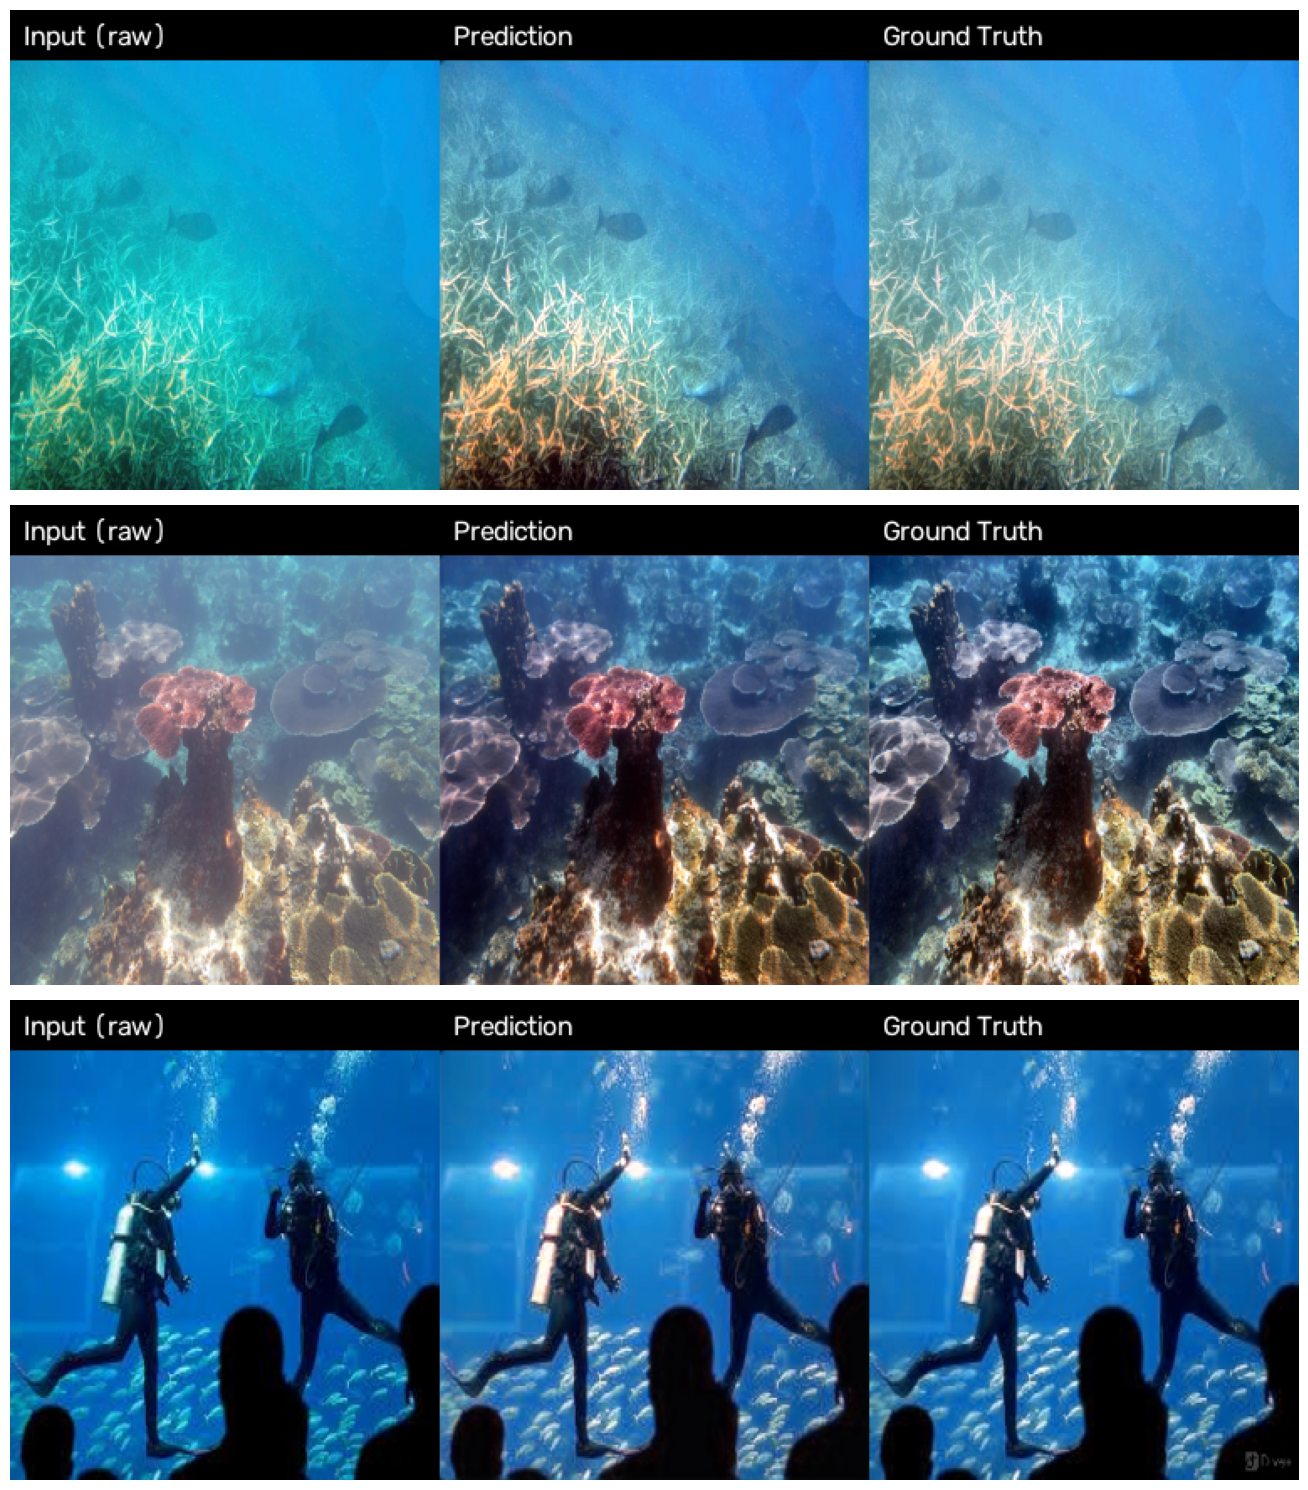

In [13]:
def put_title(image, title):
    """Add a black title bar ABOVE the image (the old version painted over the top 30 px of the image)."""
    bar = np.zeros((30, image.shape[1], 3), dtype=np.uint8)
    cv2.putText(bar, title, (8, 21), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    return np.vstack([bar, image])


def save_bgr(path, rgb):
    cv2.imwrite(str(path), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))


@torch.no_grad()
def dehaze_image(image_path, size=IMG_SIZE):
    """Run the model on one image; returns input, prediction and the forward-pass time in ms."""
    model.eval()
    with Image.open(image_path) as im:
        rgb = np.array(im.convert("RGB"))
    rgb = cv2.resize(rgb, (size, size), interpolation=cv2.INTER_AREA)
    I = np_to_tensor(rgb).unsqueeze(0).to(DEVICE)

    sync()
    t0 = time.perf_counter()
    pred = model(I)
    sync()
    infer_ms = (time.perf_counter() - t0) * 1000.0

    return {"input": rgb, "prediction": tensor_to_uint8(pred), "infer_ms": infer_ms}


def compare_one(raw_path, ref_path, output_dir):
    stem = Path(raw_path).stem
    o = dehaze_image(raw_path)

    with Image.open(ref_path) as im:
        gt = cv2.resize(np.array(im.convert("RGB")), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    panels = [put_title(o["input"], "Input (raw)"), put_title(o["prediction"], "Prediction"), put_title(gt, "Ground Truth")]

    psnr = peak_signal_noise_ratio(gt, o["prediction"], data_range=255)
    # same SSIM definition as the training code (Gaussian window, sigma=1.5)
    ssim = structural_similarity(gt, o["prediction"], channel_axis=2, data_range=255,
                                 gaussian_weights=True, sigma=1.5, use_sample_covariance=False)
    uiqm = compute_uiqm(o["prediction"])
    print(f"{stem}: PSNR={psnr:.2f} SSIM={ssim:.4f} UIQM(pred)={uiqm:.3f} inference={o['infer_ms']:.1f}ms")

    save_bgr(Path(output_dir) / f"{stem}_input.png", o["input"])
    save_bgr(Path(output_dir) / f"{stem}_prediction.png", o["prediction"])
    save_bgr(Path(output_dir) / f"{stem}_ground_truth.png", gt)
    comparison = np.hstack(panels)
    save_bgr(Path(output_dir) / f"{stem}_comparison.png", comparison)
    return comparison, {"file": Path(raw_path).name, "psnr": psnr, "ssim": ssim, "uiqm": uiqm, "infer_ms": o["infer_ms"]}


N_COMPARE = 5   # number of test images

results = [compare_one(r, g, OUTPUT_DIR) for r, g in test_pairs[:N_COMPARE]]
comparisons = [c for c, _ in results]

comparison_csv = os.path.join(LOG_DIR, "comparison_metrics.csv")
with open(comparison_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["file", "psnr", "ssim", "uiqm", "infer_ms"])
    writer.writeheader()
    writer.writerows(m for _, m in results)
print(f"Saved outputs to: {OUTPUT_DIR}\nPer-image metrics saved to {comparison_csv}")

# Display first 3 comparisons
show = comparisons[:3]
if show:
    plt.figure(figsize=(18, 5 * len(show)))
    for i, c in enumerate(show):
        plt.subplot(len(show), 1, i + 1)
        plt.imshow(c)
        plt.axis("off")
    plt.tight_layout()
    plt.show()